### Machine Learning 

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split # ML ki sabse important library

# 1. JTI Dummy Data for ML
data = {
    'Practice_Hours': [1, 2, 3, 4, 1.5, 2.5, 3.5, 4.5, 2, 3], # Clue 1
    'Mock_Score': [40, 50, 60, 70, 45, 55, 65, 75, 48, 58],   # Clue 2
    'Final_Pass': [0, 0, 1, 1, 0, 1, 1, 1, 0, 1]              # Answer (0=Fail, 1=Pass)
}
df_ml = pd.DataFrame(data)

# 2. X aur y ko alag karna
# X mein sab kuch aayega EXCEPT Final_Pass
X = df_ml.drop('Final_Pass', axis=1) 
# y mein SIRF Final_Pass aayega
y = df_ml['Final_Pass']              

# 3. The 80-20 Split
# random_state=42 ka matlab hai 'time freeze' karna. 
# Agar tu 42 likhega, toh tera aur mera data ek hi tarah se split hoga (randomness fix ho jati hai).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Total Data rows:", len(df_ml))
print("Training Data rows (X_train):", len(X_train))
print("Testing Data rows (X_test):", len(X_test))

Total Data rows: 10
Training Data rows (X_train): 8
Testing Data rows (X_test): 2


In [3]:
from sklearn.linear_model import LogisticRegression

# 1. Model ko class mein bulaya
model = LogisticRegression()

# 2. Model ko padhaya (X_train aur y_train diya)
model.fit(X_train, y_train)
print("Model ki Training Poori ho gayi!\n")

# 3. Model ka Exam liya (Sirf X_test diya)
y_pred = model.predict(X_test)

# 4. Result Check
print("Model ke diye huye Answers: ", y_pred)
print("Tere paas jo Secret Asli Answers hain (y_test): ", y_test.values)

Model ki Training Poori ho gayi!

Model ke diye huye Answers:  [0 1]
Tere paas jo Secret Asli Answers hain (y_test):  [0 0]


In [4]:
y_test

8    0
1    0
Name: Final_Pass, dtype: int64

In [6]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test, y_pred)
print(f"Model ki Accuracy: {score * 100}%")

Model ki Accuracy: 50.0%


## k Fold and its variant

In [8]:
import pandas as pd
import seaborn as sns

In [3]:
advertising= pd.read_csv('advertising.csv')
advertising

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,27-03-2016 00:53,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,04-04-2016 01:39,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,13-03-2016 20:35,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,10-01-2016 02:31,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,03-06-2016 03:36,0
...,...,...,...,...,...,...,...,...,...,...
995,72.97,30,71384.57,208.58,Fundamental modular algorithm,Duffystad,1,Lebanon,11-02-2016 21:49,1
996,51.30,45,67782.17,134.42,Grass-roots cohesive monitoring,New Darlene,1,Bosnia and Herzegovina,22-04-2016 02:07,1
997,51.63,51,42415.72,120.37,Expanded intangible solution,South Jessica,1,Mongolia,01-02-2016 17:24,1
998,55.55,19,41920.79,187.95,Proactive bandwidth-monitored policy,West Steven,0,Guatemala,24-03-2016 02:35,0


In [4]:
data=advertising._get_numeric_data()
data.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
0,68.95,35,61833.90,256.09,0,0
1,80.23,31,68441.85,193.77,1,0
2,69.47,26,59785.94,236.50,0,0
3,74.15,29,54806.18,245.89,1,0
4,68.37,35,73889.99,225.58,0,0


In [5]:
data.rename(columns={'Daily Time Spent on Site':'Time_spent',
                     'Area Income':'Area_income','Daily Internet Usage':'Net_usuage','	Clicked on Ad':'Clicked'},inplace=True)

In [6]:
data

,Time_spent,Age,Area_income,Net_usuage,Male,Clicked on Ad
0,68.95,35,61833.90,256.09,0,0
1,80.23,31,68441.85,193.77,1,0
2,69.47,26,59785.94,236.50,0,0
3,74.15,29,54806.18,245.89,1,0
4,68.37,35,73889.99,225.58,0,0
...,...,...,...,...,...,...
995,72.97,30,71384.57,208.58,1,1
996,51.30,45,67782.17,134.42,1,1
997,51.63,51,42415.72,120.37,1,1
998,55.55,19,41920.79,187.95,0,0


In [7]:
data.rename(columns={'Clicked on Ad':'Clicked'},inplace=True)
data

,Time_spent,Age,Area_income,Net_usuage,Male,Clicked
0,68.95,35,61833.90,256.09,0,0
1,80.23,31,68441.85,193.77,1,0
2,69.47,26,59785.94,236.50,0,0
3,74.15,29,54806.18,245.89,1,0
4,68.37,35,73889.99,225.58,0,0
...,...,...,...,...,...,...
995,72.97,30,71384.57,208.58,1,1
996,51.30,45,67782.17,134.42,1,1
997,51.63,51,42415.72,120.37,1,1
998,55.55,19,41920.79,187.95,0,0


In [9]:
import statsmodels.formula.api as smf

In [10]:
base_model1=smf.logit('Clicked~Time_spent+Age+Area_income+Net_usuage+Male',data=data).fit()
print(base_model1.summary())

Optimization terminated successfully.
         Current function value: 0.090904
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                Clicked   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      994
Method:                           MLE   Df Model:                            5
Date:                Mon, 18 May 2026   Pseudo R-squ.:                  0.8689
Time:                        18:53:27   Log-Likelihood:                -90.904
converged:                       True   LL-Null:                       -693.15
Covariance Type:            nonrobust   LLR p-value:                3.136e-258
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      27.3606      2.736      9.999      0.000      21.997      32.724
Time_spent     -0.1927   

In [11]:
clean_data=data.drop(['Male'],axis=1)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score
X=clean_data.drop(['Clicked'],axis=1)
y=clean_data['Clicked']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
final_mod=LogisticRegression()
final_mod.fit(X_train_scaled,y_train)
test_pred=final_mod.predict(X_test_scaled)
print( list(y_test))
print(list(test_pred))
acc=accuracy_score(y_test,test_pred)
print('Model accuracy is :', acc)

[1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1]
[1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1,

Confusion matrix number:
 [[ 86   3]
 [  7 104]]


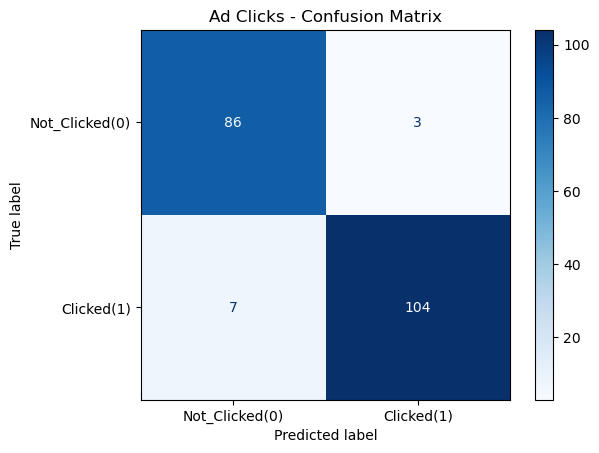

In [13]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test,test_pred)
print('Confusion matrix number:\n',cm)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Not_Clicked(0)','Clicked(1)'])
disp.plot(cmap='Blues')
plt.title("Ad Clicks - Confusion Matrix")
plt.show()

In [14]:
y_pred_prob=final_mod.predict_proba(X_test_scaled)[: , 1]
custom_threshold=0.3
custom_pred=(y_pred_prob>=custom_threshold).astype(int)
print('New matrix after threshold 0.3 is:')
print(confusion_matrix(y_test,custom_pred))

New matrix after threshold 0.3 is:
[[ 81   8]
 [  4 107]]


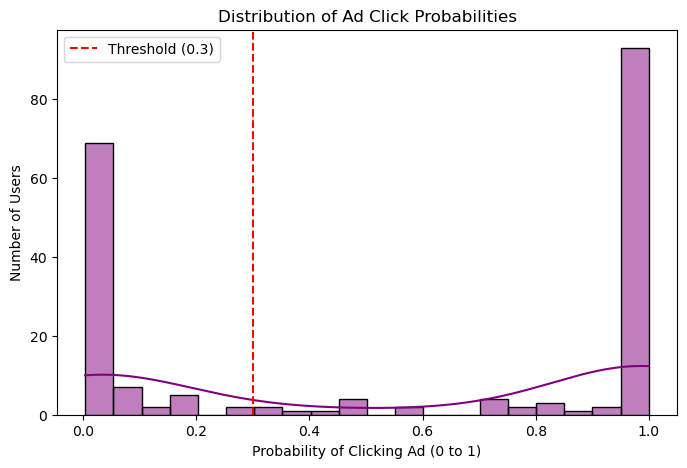

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Jo probabilities tune nikali thi, unka ek Histogram banayenge
plt.figure(figsize=(8,5))
sns.histplot(y_pred_prob, bins=20, kde=True, color='purple')

# Ek line banayenge jo tera 0.3 ka naya threshold (passing mark) dikhayegi
plt.axvline(x=0.3, color='red', linestyle='--', label='Threshold (0.3)')

plt.title("Distribution of Ad Click Probabilities")
plt.xlabel("Probability of Clicking Ad (0 to 1)")
plt.ylabel("Number of Users")
plt.legend()
plt.show()

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error


In [19]:
clean_data

,Time_spent,Age,Area_income,Net_usuage,Clicked
0,68.95,35,61833.90,256.09,0
1,80.23,31,68441.85,193.77,0
2,69.47,26,59785.94,236.50,0
3,74.15,29,54806.18,245.89,0
4,68.37,35,73889.99,225.58,0
...,...,...,...,...,...
995,72.97,30,71384.57,208.58,1
996,51.30,45,67782.17,134.42,1
997,51.63,51,42415.72,120.37,1
998,55.55,19,41920.79,187.95,0


In [22]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

# 1. Features aur Target ready karo
X_kv = clean_data.drop(['Clicked'], axis=1).values # .values lagane se array ban jata hai jo KFold ke liye best hai
y_kv = clean_data['Clicked'].values

# 2. K-Fold Ka Engine Set Karo (K=5)
# shuffle=True matlab data ko fold mein baantne se pehle ache se mix (petein) karo
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Model validation chalao
model_kf = LogisticRegression()
scores_kf = cross_val_score(model_kf, X_kv, y_kv, cv=kf)

# 4. Results Print Karo
print("Har fold ka score:", scores_kf)
print(f"Standard K-Fold Average Accuracy: {scores_kf.mean() * 100:.2f}%")
print(f"Scores ke beech ka Variance (Standard Deviation): {scores_kf.std():.4f}")

Har fold ka score: [0.9  0.9  0.9  0.87 0.97]
Standard K-Fold Average Accuracy: 90.80%
Scores ke beech ka Variance (Standard Deviation): 0.0331
